In [7]:
import networkx as nx
import asymmetree.treeevolve as te
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import random
import numpy as np

from asymmetree.visualization.tree_vis import visualize, assign_colors
from asymmetree.analysis import orthology_from_tree, bmg_from_tree
from tralda.datastructures.tree import TreeNode
import insertHybrid
from networkx.drawing.nx_pydot import graphviz_layout
from collections import defaultdict

seed = 1
random.seed(seed)
np.random.seed(seed)

In [8]:
# Zufälligen Genbaum von Assymetree erstellen lassen.
# generate Species Tree

S = te.species_tree_n(n = 3)

# generate Gene Tree

dated_gene_tree = te.dated_gene_tree(
    S,
    dupl_rate=0.5,
    loss_rate=0.1,
    hgt_rate=0,
    dupl_polytomy=0.5   #### hier kann die ANzahl der durchschnittlichen Kinder ausgewählt werden
)

full_gene_tree = te.rate_heterogeneity(
    dated_gene_tree,
    S,
    base_rate=0.5,
    autocorr_variance=0.2,
)

# prune all loss branches and the planted root
pruned_gene_tree = te.prune_losses(full_gene_tree)

species_colors, gene_colors = assign_colors(S, pruned_gene_tree)
# reverse dict so every color has a list of leaves attached to it, for visualization
color_to_keys = defaultdict(list)
for key, color in gene_colors.items():
    color_to_keys[tuple(color)].append(key)

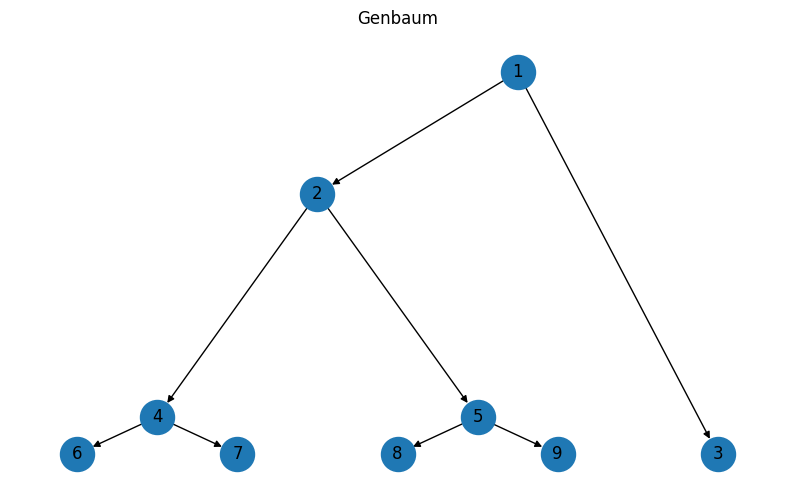

[(1, {'label': 1, 'event': 'S', 'reconc': 1, 'tstamp': 0.7056169168933035, 'transferred': 0, 'dist': 0.0}), (2, {'label': 2, 'event': 'D', 'reconc': (1, 3), 'tstamp': 0.4811969514125821, 'transferred': 0, 'dist': np.float64(0.112940273606015), 'sibling_nr': 0}), (4, {'label': 4, 'event': 'S', 'reconc': 3, 'tstamp': 0.0685542903866514, 'transferred': 0, 'dist': np.float64(0.2975060650307674), 'sibling_nr': 0}), (6, {'label': 6, 'event': 'S', 'reconc': 4, 'tstamp': 0.0, 'transferred': 0, 'dist': np.float64(0.048813318105592945), 'sibling_nr': 0}), (7, {'label': 7, 'event': 'S', 'reconc': 5, 'tstamp': 0.0, 'transferred': 0, 'dist': np.float64(0.22773566450870095), 'sibling_nr': 1}), (5, {'label': 5, 'event': 'S', 'reconc': 3, 'tstamp': 0.0685542903866514, 'transferred': 0, 'dist': np.float64(0.33874983122741914), 'sibling_nr': 1}), (8, {'label': 8, 'event': 'S', 'reconc': 4, 'tstamp': 0.0, 'transferred': 0, 'dist': np.float64(0.07850852686614694), 'sibling_nr': 0}), (9, {'label': 9, 'even

In [9]:
N = insertHybrid.convert_to_nx(pruned_gene_tree)

# ── Labels: node.label Attribut ──────────────────────────
labels = {n: N.nodes[n]['label'] for n in N.nodes}

pos = insertHybrid.calculate_time_tree_layout(N)

fig, ax = plt.subplots(figsize=(10, 6))

nx.draw(N,pos= pos,
        labels=labels,
        node_size=600,
        arrows=True,
        ax=ax)

plt.title('Genbaum')
plt.show()

print(N.nodes(data = True))

Es wurde ein Hybrid zwischen node 2 und node 5 eingefügt und dieser wurde mit Node 7 verbunden
Es wurde ein Hybrid zwischen node 10 und node 7 eingefügt und dieser wurde mit Node 9 verbunden
Es wurde ein Hybrid zwischen node 5 und node 8 eingefügt und dieser wurde mit Node 6 verbunden
Es wurde ein Hybrid zwischen node 1 und node 3 eingefügt und dieser wurde mit Node 5 verbunden
Es wurde ein Hybrid zwischen node 1 und node 13 eingefügt und dieser wurde mit Node 10 verbunden
Es wurde ein Hybrid zwischen node 1 und node 14 eingefügt und dieser wurde mit Node 6 verbunden
Es wurde ein Hybrid zwischen node 11 und node 9 eingefügt und dieser wurde mit Node 12 verbunden
Es wurde ein Hybrid zwischen node 2 und node 4 eingefügt und dieser wurde mit Node 16 verbunden
Es wurde ein Hybrid zwischen node 13 und node 5 eingefügt und dieser wurde mit Node 7 verbunden
Es wurde ein Hybrid zwischen node 10 und node 5 eingefügt und dieser wurde mit Node 4 verbunden


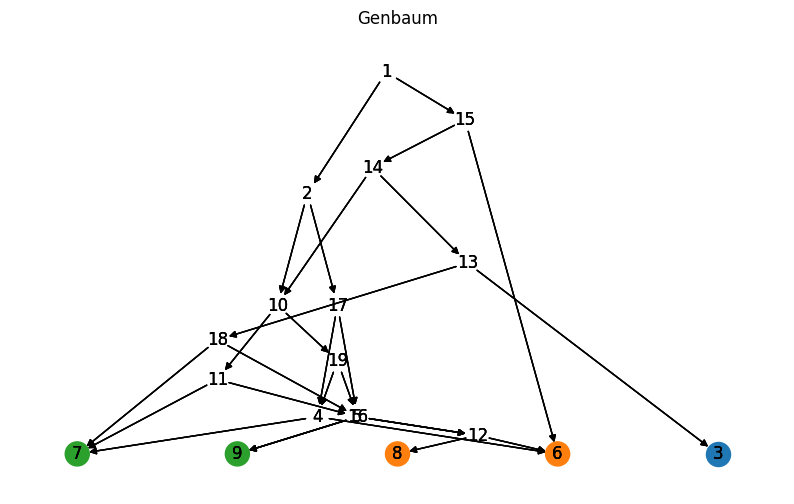

In [10]:
N = insertHybrid.insertHybrid(N,10)

# ── Labels: node.label Attribut ──────────────────────────
labels = {n: N.nodes[n]['label'] for n in N.nodes}

pos = insertHybrid.calculate_time_tree_layout(N)

# ── Plot ──────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))

for color, node_list in color_to_keys.items():
    nx.draw(N,
            pos,
            nodelist=node_list,
            node_color=[color] * len(node_list),
            with_labels=True)

plt.title('Genbaum')
plt.show()

# for node in G.nodes(data=True):
#     print(node)

False


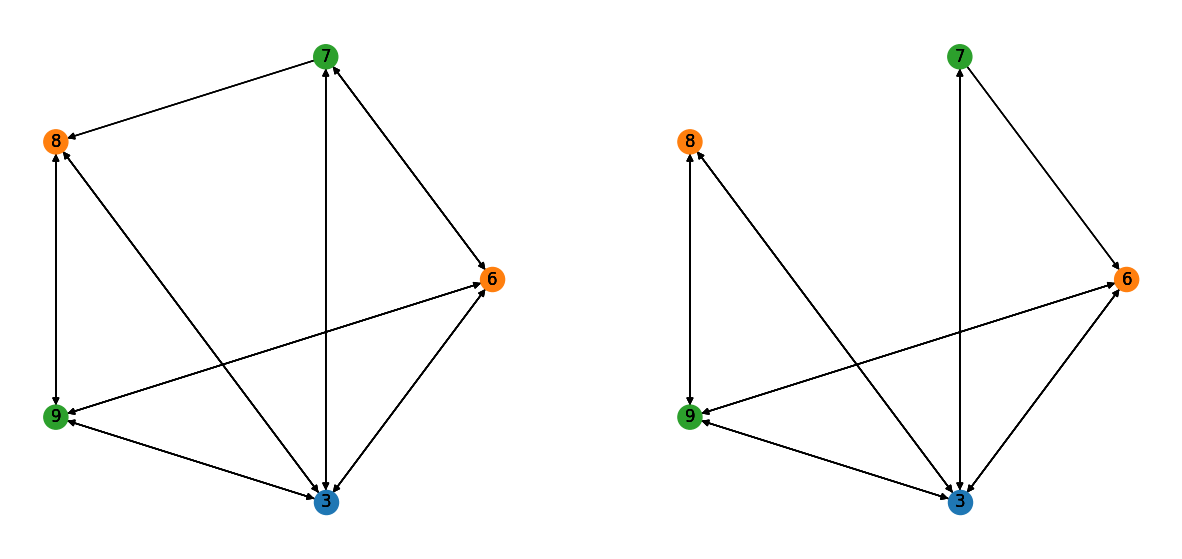

In [11]:
BMG = insertHybrid.bmg(N)
BMG_strong = insertHybrid.bmg(N,"strong")

print(nx.utils.graphs_equal(BMG, BMG_strong))

ig, axes = plt.subplots(1, 2, figsize=(15, 7))
# Tree BMG
for color, node_list in color_to_keys.items():
    nx.draw(BMG, nx.circular_layout(BMG), nodelist=node_list, node_color=[color] * len(node_list), ax=axes[0], with_labels=True)
# network BMG
for color, node_list in color_to_keys.items():
    nx.draw(BMG_strong, nx.circular_layout(BMG_strong), nodelist=node_list, node_color=[color] * len(node_list), ax=axes[1], with_labels=True)

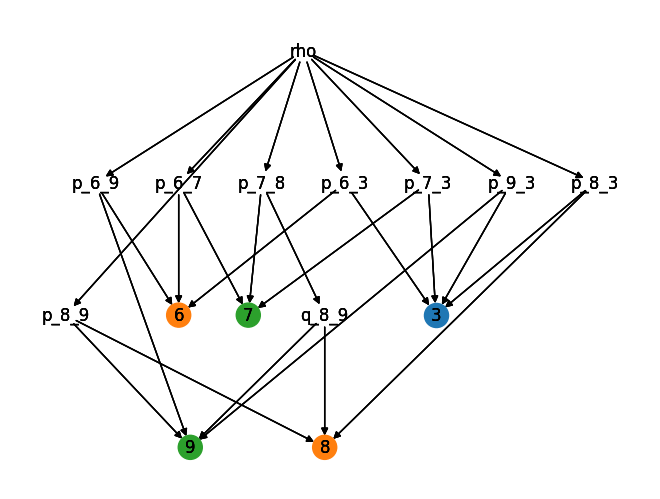

In [12]:
BCN = insertHybrid.biccherry(BMG)


for color, node_list in color_to_keys.items():
    nx.draw(BCN, graphviz_layout(BCN, prog="dot"), nodelist=node_list, node_color=[color] * len(node_list), with_labels=True)
plt.show()

In [13]:
BMGre = insertHybrid.bmg(BCN)
print(nx.utils.graphs_equal(BMG, BMGre))

True


# offene Fragen:
- bei BIC-Cherry Extension: Kann man z einfach random wählen? Oder wäre es sinnvoller, den BM von x zu nehmen?
- kann man p_8_9 löschen?